# Đánh giá hiệu quả của DeepFilterNet (Denoise) cho luồng xử lý Audio

Notebook này nhằm mục đích thử nghiệm và đánh giá xem việc thêm model **DeepFilterNet** vào luồng xử lý âm thanh có cải thiện được chất lượng nhận dạng giọng nói (ASR) của Faster-Whisper hay không.

### Các chỉ số được đo lường:
1. **WER (Word Error Rate)** & **CER (Character Error Rate)**: Tỉ lệ lỗi từ và lỗi ký tự (càng thấp càng tốt). Đây là chỉ số quan trọng nhất.
2. **SNR (Signal-to-Noise Ratio)**: Ước lượng tỉ lệ tín hiệu trên nhiễu để xem chất lượng audio có thực sự "sạch" hơn không.
3. **Latency Overhead**: Thời gian xử lý tăng thêm khi chạy qua model DeepFilterNet.

**Dataset**: `distil-whisper/tedlium` (Test split) - Đã có sẵn ground truth transcript.

In [1]:
# Cài đặt các thư viện cần thiết. 
# Ép phiên bản datasets < 3.0.0 để tương thích với các custom script cũ của TEDLIUM
# !pip install "datasets<3.0.0" deepfilternet faster-whisper jiwer torchaudio pandas matplotlib seaborn numpy

## 1. Import Thư viện & Thiết lập

In [2]:
import time
import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
import jiwer
from datasets import load_dataset
from faster_whisper import WhisperModel

from df.enhance import enhance, init_df, load_audio, save_audio
from df.utils import download_file

# Hiển thị đồ thị ngay trong notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

C:\Users\PHAM MINH DUC\AppData\Roaming\Python\Python311\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.5.1+cpu
CUDA available: False


C:\Users\PHAM MINH DUC\AppData\Roaming\Python\Python311\site-packages\df\io.py:9: UserWarning: `torchaudio.backend.common.AudioMetaData` has been moved to `torchaudio.AudioMetaData`. Please update the import path.
  from torchaudio.backend.common import AudioMetaData


## 2. Load Dataset và Models
Bởi vì các model `faster-whisper-base.en` và dataset `distil-whisper/tedlium` đã được cache trong máy, bước này sẽ chạy rất nhanh.

In [3]:
print("Loading dataset...")
# Tải tập test của tedlium bằng cấu hình release3, dùng streaming để không phải tải toàn bộ file nặng
dataset = load_dataset("distil-whisper/tedlium", "release3", split="test", trust_remote_code=True, streaming=True)

# Bỏ hàm len(dataset) vì IterableDataset (khi streaming=True) không hỗ trợ hàm len()
print("Dataset loaded successfully in streaming mode.")

# Load Faster-Whisper Model
print("Loading Faster-Whisper model...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

whisper_model = WhisperModel("base.en", device=device, compute_type=compute_type)

# Load DeepFilterNet Model
print("Loading DeepFilterNet model...")
df_model, df_state, _ = init_df()  # Tự động tải model tốt nhất (DeepFilterNet3) vào RAM/VRAM

print("All models loaded successfully!")

Loading dataset...
Dataset loaded successfully in streaming mode.
Loading Faster-Whisper model...
Loading DeepFilterNet model...
2026-08-03 12:15:55 | INFO     | DF | Running on torch 2.5.1+cpu
2026-08-03 12:15:55 | INFO     | DF | Running on host DESKTOP-9RK5OJN
2026-08-03 12:15:55 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-08-03 12:15:55 | INFO     | DF | Using DeepFilterNet3 model at C:\Users\PHAM MINH DUC\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3
2026-08-03 12:15:55 | INFO     | DF | Initializing model `deepfilternet3`
2026-08-03 12:15:55 | INFO     | DF | Found checkpoint C:\Users\PHAM MINH DUC\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3\checkpoints\model_120.ckpt.best with epoch 120
2026-08-03 12:15:55 | INFO     | DF | Running on device cpu
2026-08-03 12:15:55 | INFO     | DF | Model loaded
All models loaded successfully!


C:\Users\PHAM MINH DUC\AppData\Roaming\Python\Python311\site-packages\df\checkpoint.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  latest = torch.load(latest, map_loca

## 3. Các Hàm Hỗ trợ (Pipeline & Metrics)

In [4]:
def calculate_snr(audio_tensor):
    """
    Ước lượng SNR (Signal-to-Noise Ratio) thô.
    """
    if not isinstance(audio_tensor, torch.Tensor):
        audio_tensor = torch.tensor(audio_tensor)
    
    signal_power = torch.mean(audio_tensor ** 2)
    sorted_vals, _ = torch.sort(torch.abs(audio_tensor))
    noise_idx = int(0.1 * len(sorted_vals))
    noise_power = torch.mean(sorted_vals[:noise_idx] ** 2)
    
    if noise_power == 0:
        return 100.0
    
    snr = 10 * torch.log10(signal_power / noise_power)
    return snr.item()

def transcribe_audio(audio_array, sample_rate):
    """Chạy Whisper để lấy transcript."""
    segments, info = whisper_model.transcribe(audio_array, beam_size=5)
    text = " ".join([segment.text for segment in segments])
    return text.strip()

def process_baseline(audio_array, sample_rate):
    """Pipeline chỉ dùng Whisper."""
    start_time = time.time()
    transcript = transcribe_audio(audio_array, sample_rate)
    latency = time.time() - start_time
    snr = calculate_snr(audio_array)
    return transcript, latency, snr

def process_denoised(audio_array, sample_rate):
    """Pipeline dùng DeepFilterNet sau đó qua Whisper."""
    start_time = time.time()
    audio_tensor = torch.tensor(audio_array, dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        enhanced_audio = enhance(df_model, df_state, audio_tensor)
        
    enhanced_array = enhanced_audio.squeeze().cpu().numpy()
    transcript = transcribe_audio(enhanced_array, sample_rate)
    latency = time.time() - start_time
    snr = calculate_snr(enhanced_array)
    return transcript, latency, snr

def normalize_text(text):
    import re
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

## 4. Thực thi Đánh giá
Chúng ta sẽ chạy trên một tập con (`NUM_SAMPLES`) để xem kết quả nhanh.

In [5]:
NUM_SAMPLES = 50
results = []

print(f"Bắt đầu đánh giá trên {NUM_SAMPLES} mẫu...")

# Sửa lỗi: Vì dùng streaming=True (IterableDataset), ta phải dùng hàm .take() thay vì index [i]
for i, sample in enumerate(dataset.take(NUM_SAMPLES)):
    audio_data = sample['audio']['array']
    sample_rate = sample['audio']['sampling_rate']
    ground_truth_raw = sample['text']
    
    # Nếu mẫu rỗng, bỏ qua
    if not ground_truth_raw.strip():
        continue
        
    ref_text = normalize_text(ground_truth_raw)
    
    # 1. Baseline
    hyp_base, lat_base, snr_base = process_baseline(audio_data, sample_rate)
    hyp_base = normalize_text(hyp_base)
    
    # Tính WER/CER
    wer_base = jiwer.wer(ref_text, hyp_base)
    cer_base = jiwer.cer(ref_text, hyp_base)
    
    # 2. Denoised
    hyp_den, lat_den, snr_den = process_denoised(audio_data, sample_rate)
    hyp_den = normalize_text(hyp_den)
    
    wer_den = jiwer.wer(ref_text, hyp_den)
    cer_den = jiwer.cer(ref_text, hyp_den)
    
    # Lưu kết quả
    results.append({
        'sample_id': i,
        'ref_length': len(ref_text.split()),
        'wer_baseline': wer_base,
        'cer_baseline': cer_base,
        'snr_baseline': snr_base,
        'latency_baseline': lat_base,
        'wer_denoised': wer_den,
        'cer_denoised': cer_den,
        'snr_denoised': snr_den,
        'latency_denoised': lat_den,
    })
    
    if (i + 1) % 10 == 0:
        print(f"Đã xử lý {i + 1}/{NUM_SAMPLES}...")

df_results = pd.DataFrame(results)
print("Hoàn thành xử lý!")

Bắt đầu đánh giá trên 50 mẫu...
Đã xử lý 10/50...
Đã xử lý 20/50...
Đã xử lý 30/50...
Đã xử lý 40/50...
Đã xử lý 50/50...
Hoàn thành xử lý!


## 5. Kết quả & Trực quan hóa

In [6]:
# Tóm tắt trung bình
summary = df_results[['wer_baseline', 'wer_denoised', 
                      'cer_baseline', 'cer_denoised', 
                      'snr_baseline', 'snr_denoised', 
                      'latency_baseline', 'latency_denoised']].mean()

print("========= BẢNG TÓM TẮT TRUNG BÌNH =========")
print(f"WER (Baseline vs Denoised) : {summary['wer_baseline']:.4f} vs {summary['wer_denoised']:.4f}")
print(f"CER (Baseline vs Denoised) : {summary['cer_baseline']:.4f} vs {summary['cer_denoised']:.4f}")
print(f"SNR (Baseline vs Denoised) : {summary['snr_baseline']:.2f} dB vs {summary['snr_denoised']:.2f} dB")
print(f"Latency (Base vs Denoised) : {summary['latency_baseline']:.2f} s vs {summary['latency_denoised']:.2f} s")
print(f"Overhead thời gian: {summary['latency_denoised'] - summary['latency_baseline']:.2f} s/mẫu")

========= BẢNG TÓM TẮT TRUNG BÌNH =========
WER (Baseline vs Denoised) : 0.9928 vs 0.9403
CER (Baseline vs Denoised) : 0.2818 vs 0.8081
SNR (Baseline vs Denoised) : 36.13 dB vs 52.70 dB
Latency (Base vs Denoised) : 2.07 s vs 5.07 s
Overhead thời gian: 3.01 s/mẫu


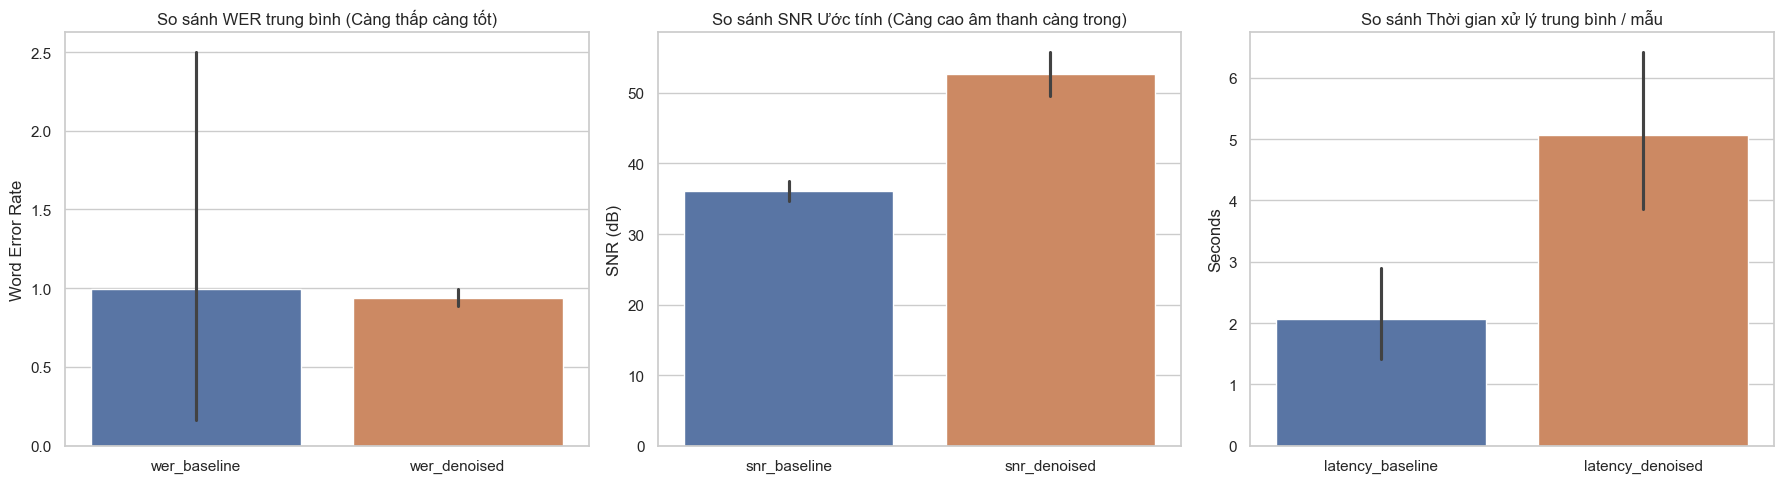

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. WER Comparison
sns.barplot(data=df_results[['wer_baseline', 'wer_denoised']], ax=axes[0])
axes[0].set_title('So sánh WER trung bình (Càng thấp càng tốt)')
axes[0].set_ylabel('Word Error Rate')

# 2. SNR Comparison
sns.barplot(data=df_results[['snr_baseline', 'snr_denoised']], ax=axes[1])
axes[1].set_title('So sánh SNR Ước tính (Càng cao âm thanh càng trong)')
axes[1].set_ylabel('SNR (dB)')

# 3. Latency Comparison
sns.barplot(data=df_results[['latency_baseline', 'latency_denoised']], ax=axes[2])
axes[2].set_title('So sánh Thời gian xử lý trung bình / mẫu')
axes[2].set_ylabel('Seconds')

plt.tight_layout()
plt.show()